# Boston SARS-CoV-2: EpiLink-Leiden vs. dated-tree TreeCluster

Two clustering paradigms run on the **same** Boston samples, then cross-compared.

1. **TreeCluster** — aligned FASTA -> VeryFastTree -> TreeTime (dated tree) ->
   TreeCluster, swept over a grid of **time thresholds** (`max_clade`, years on the
   dated tree).
2. **EpiLink-Leiden** — pairwise EpiLink compatibility scores -> weighted graph ->
   Leiden community detection, swept over a grid of **resolutions**.

The final heatmap measures partition similarity (**Adjusted Rand Index**) between the
two methods at every (Leiden resolution x TreeCluster threshold) combination — x-axis
is the EpiLink-Leiden resolution, y-axis is the TreeCluster threshold.

## Setup

In [38]:
import io
import os
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# Make the evaluation package and its bare-import modules importable.
SRC = Path("src").resolve()
for _p in (str(SRC), str(SRC / "evaluation")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from evaluation.config import (  # noqa: E402
    get_config_value,
    load_config,
    resolve_inference_baseline_parameters,
)
from evaluation.boston import add_temporal_distance  # noqa: E402
from evaluation.leiden import build_weighted_graph, run_leiden_partition  # noqa: E402
from evaluation.models import build_linkage_model  # noqa: E402
from evaluation.specs import DEFAULT_SEED  # noqa: E402
from evaluation.plotting import (  # noqa: E402
    PLOS_WIDTHS_CM,
    cm_to_inch,
    save_plos_figure,
    set_plos_theme,
    add_panel_labels,
)

In [39]:
# ---- inputs ----
ALN = "data/raw/boston/MGH_DPH_98percent_772samples_aligned.fasta"  # headers must match SAMPLE_COL
METADATA = "data/processed/boston/boston_metadata.parquet"
PAIRWISE = "data/processed/boston/boston_pairwise_distances.parquet"
SAMPLE_COL = "SeqID"  # sequence/sample names
DATE_COL = "Date"  # collection dates (YYYY-MM-DD, YYYY-MM, or decimal year)
PAIR_ID_1, PAIR_ID_2 = "SeqID1", "SeqID2"
GENETIC_COL = "SNP_Distance"

# ---- tree / dating parameters ----
OUTDIR = "phylo"
THREADS = 4
CLOCK_FILTER = 3  # drop tips > N IQDs off the clock; 0 disables
CLUSTER_METHOD = "max_clade"

# ---- comparison grids ----
LEIDEN_RESOLUTIONS = np.round(np.arange(0.1, 1.01, 0.1), 2)  # EpiLink-Leiden (x-axis)
TC_THRESHOLD_DAYS = np.arange(7.0, 77.0, 7.0)  # TreeCluster (y-axis)

# ---- EpiLink / Leiden config (matched-baseline inference parameters) ----
config = load_config("config.yaml")
INFERENCE_PARAMS = resolve_inference_baseline_parameters(config)
MIN_EDGE_WEIGHT = float(
    get_config_value(config, "workflows.boston.minimum_edge_weight", default=0.0001)
)
N_RESTARTS = int(get_config_value(config, "workflows.boston.n_restarts", default=10))
WEIGHT_COL = "EpiLinkStochasticScore"
TEMPORAL_COL = "Temporal_Distance"

# ---- derived paths ----
os.makedirs(OUTDIR, exist_ok=True)
TREE = f"{OUTDIR}/tree.nwk"
DATES = f"{OUTDIR}/dates.csv"
TT_DIR = f"{OUTDIR}/treetime"
TIMETREE_NEX = f"{TT_DIR}/timetree.nexus"
TIMETREE_NWK = f"{OUTDIR}/timetree.nwk"


## Step 1 — TreeTime dates file

TreeTime wants a `name,date` CSV; pull it from the metadata.

In [40]:
meta = pd.read_parquet(METADATA)
missing = [c for c in (SAMPLE_COL, DATE_COL) if c not in meta.columns]
assert not missing, f"Missing column(s) {missing}. Found: {meta.columns.tolist()}"

dates = meta[[SAMPLE_COL, DATE_COL]].dropna()
dates.columns = ["name", "date"]
dates.to_csv(DATES, index=False)
print(f"{len(dates)} dated samples written to {DATES}")
dates.head()

772 dated samples written to phylo/dates.csv


,name,date
0,MA_MGH_00003,2020-03-09
1,MA_MGH_00004,2020-03-11
2,MA_MGH_00005,2020-03-11
3,MA_MGH_00006,2020-03-11
4,MA_MGH_00013,2020-03-23


## Step 2 — genetic tree (VeryFastTree)

`-double-precision` is **required** for SARS-CoV-2: long, closely-related sequences lose
branch-length accuracy in single precision, which would corrupt the dating and
clustering. Swap to `iqtree2` for a slower/more accurate build.

In [41]:
!VeryFastTree -nt -gtr -double-precision -threads {THREADS} {ALN} > {TREE}
assert os.path.getsize(TREE) > 0, "tree build failed — check the output above"
print("tree:", TREE)

Command: VeryFastTree -nt -gtr -double-precision -threads 4 data/raw/boston/MGH_DPH_98percent_772samples_aligned.fasta
VeryFastTree Version 4.0.5 (OpenMP) Double precision using threads(4) level 3 deterministic
Alignment: data/raw/boston/MGH_DPH_98percent_772samples_aligned.fasta
Nucleotide distances: Jukes-Cantor Joins: balanced Support: SH-like 1000
Search: Normal +NNI +SPR (2 rounds range 10) +ML-NNI opt-each=1
TopHits: 1.00*sqrtN close=default refresh=0.80
ML Model: Generalized Time-Reversible, CAT approximation with 20 rate categories
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
Ignored unknown character X (seen 19141 times)
Ignored unknown character Y (seen 1 times)
Initial topology in 6.42 seconds0 of    645    1 of    648 seqs    500)   
Refining topology: 37 rounds ME-NNIs, 2 rounds ME-SPRs, 19 rounds ML-NNIs
Total branch-length 0.024 after 44.44 sec, 404 of 646 splits, 0 changes   ax delta 0.000)    

WARNING! This alignment

## Step 3 — time-calibrate (TreeTime)

Branch lengths become calendar years. TreeTime **reroots by default** — append
`--keep-root` if your tree is already rooted. `--clock-filter` drops temporal outliers.

In [42]:
clock = f"--clock-filter {CLOCK_FILTER}" if CLOCK_FILTER else ""
!treetime --tree {TREE} --aln {ALN} --dates {DATES} {clock} --outdir {TT_DIR}
assert os.path.exists(TIMETREE_NEX), (
    "TreeTime produced no timetree — check output above"
)
print("dated tree:", TIMETREE_NEX)


Attempting to parse dates...
	Using column 'name' as name. This needs match the taxon names in the tree!!
	Using column 'date' as date.

0.00	-TreeAnc: set-up

9.74	TreeTime.reroot: with method or node: least-squares

9.75	TreeTime.reroot: rerooting will ignore covariance and shared ancestry.

10.70	TreeTime.reroot: with method or node: least-squares

10.70	TreeTime.reroot: rerooting will ignore covariance and shared ancestry.

12.91	###TreeTime.run: INITIAL ROUND

18.58	TreeTime.reroot: with method or node: least-squares

18.59	TreeTime.reroot: rerooting will ignore covariance and shared ancestry.

19.43	###TreeTime.run: rerunning timetree after rerooting

26.01	###TreeTime.run: ITERATION 1 out of 2 iterations

26.01	DEPRECATION WARNING. TreeTime.resolve_polytomies: You are resolving
     	polytomies using the old 'greedy' mode. This is not well suited for large
     	polytomies. Stochastic resolution will become the default in future
     	versions. To switch now, rerun with the fla

### Check temporal signal

Weak signal -> unreliable node dates. Inspect before trusting the dating.

In [43]:
clk = os.path.join(TT_DIR, "molecular_clock.txt")
if os.path.exists(clk):
    print(open(clk).read())
reg = os.path.join(TT_DIR, "root_to_tip_regression.pdf")
print("Root-to-tip regression plot:", reg if os.path.exists(reg) else "(not found)")

Root-Tip-Regression:
 --rate:	5.912e-04
 --r^2:  	0.17


Root-to-tip regression plot: phylo/treetime/root_to_tip_regression.pdf


## Step 4 — dated tree -> Newick (gotree)

TreeTime writes NEXUS; TreeCluster reads Newick. gotree preserves the year-scaled
branch lengths.

In [44]:
!gotree reformat newick -i {TIMETREE_NEX} -f nexus -o {TIMETREE_NWK}
assert os.path.getsize(TIMETREE_NWK) > 0, "nexus->newick conversion failed"
print("dated newick:", TIMETREE_NWK)

2026/06/03 13:51:35 Newick : Branch lengths attached to root node are ignored
dated newick: phylo/timetree.nwk


## Step 5 — TreeCluster across a time-threshold grid

Run TreeCluster on the **dated** tree for each threshold; `-t` is a clade time-depth in
years (swept here as days/365). `-1` marks singletons. We keep a `{SeqID -> cluster}`
map per threshold for the comparison.

In [45]:
def treecluster_partition(newick_path, threshold_years, method):
    # Run TreeCluster and return {SeqID: cluster_id} (-1 = singleton).
    proc = subprocess.run(
        [
            "TreeCluster.py",
            "-i",
            str(newick_path),
            "-t",
            str(threshold_years),
            "-m",
            method,
        ],
        capture_output=True,
        text=True,
        check=True,
    )
    df = pd.read_csv(io.StringIO(proc.stdout), sep="\t")
    df.columns = ["SequenceName", "ClusterNumber"]
    return dict(zip(df["SequenceName"], df["ClusterNumber"].astype(int)))


treecluster_partitions = {}
for days in TC_THRESHOLD_DAYS:
    partition = treecluster_partition(TIMETREE_NWK, float(days) / 365.0, CLUSTER_METHOD)
    treecluster_partitions[float(days)] = partition
    n_clusters = len({c for c in partition.values() if c != -1})
    n_singletons = sum(1 for c in partition.values() if c == -1)
    print(f"t={days:5.0f}d  {n_clusters:4d} clusters  {n_singletons:4d} singletons")

t=    7d    95 clusters   475 singletons
t=   14d   101 clusters   438 singletons
t=   21d   105 clusters   401 singletons
t=   28d   111 clusters   354 singletons
t=   35d   111 clusters   321 singletons
t=   42d   112 clusters   276 singletons
t=   49d   107 clusters   249 singletons
t=   56d   102 clusters   233 singletons
t=   63d   102 clusters   213 singletons
t=   70d   103 clusters   200 singletons


## Step 6 — EpiLink-Leiden across a resolution grid

Score every pair with the matched-baseline **stochastic** EpiLink model (time difference
+ SNP distance), build a weighted graph, and run multi-restart Leiden at each resolution.
Higher resolution -> more, smaller clusters.

In [46]:
pair = pd.read_parquet(PAIRWISE)
pair = add_temporal_distance(
    pair, meta, SAMPLE_COL, PAIR_ID_1, PAIR_ID_2, DATE_COL, TEMPORAL_COL
)

model = build_linkage_model(
    INFERENCE_PARAMS, mutation_process="stochastic", rng_seed=DEFAULT_SEED
)
pair[WEIGHT_COL] = np.asarray(
    model.score_target(
        sample_time_difference=pair[TEMPORAL_COL].to_numpy(),
        genetic_distance=pair[GENETIC_COL].to_numpy(),
    ),
    dtype=float,
)

all_ids = pd.unique(pair[[PAIR_ID_1, PAIR_ID_2]].values.ravel())
graph = build_weighted_graph(
    minimum_weight=MIN_EDGE_WEIGHT,
    pairwise_frame=pair,
    weight_column=WEIGHT_COL,
    source_column=PAIR_ID_1,
    target_column=PAIR_ID_2,
    vertex_ids=all_ids,
)


def leiden_partition(resolution):
    # Run multi-restart Leiden and return {SeqID: cluster_id}.
    partition, _ = run_leiden_partition(
        graph,
        WEIGHT_COL,
        float(resolution),
        num_restarts=N_RESTARTS,
        rng_seed=DEFAULT_SEED,
    )
    return {
        graph.vs[i]["case_id"]: partition.membership[i] for i in range(graph.vcount())
    }


leiden_partitions = {}
for resolution in LEIDEN_RESOLUTIONS:
    partition = leiden_partition(resolution)
    leiden_partitions[float(resolution)] = partition
    print(f"resolution={resolution:.1f}  {len(set(partition.values())):4d} clusters")

resolution=0.1   134 clusters
resolution=0.2   175 clusters
resolution=0.3   208 clusters
resolution=0.4   238 clusters
resolution=0.5   306 clusters
resolution=0.6   411 clusters
resolution=0.7   527 clusters
resolution=0.8   670 clusters
resolution=0.9   772 clusters
resolution=1.0   772 clusters


## Step 7 — cluster-similarity heatmaps (ARI + AMI)

For every (Leiden resolution, TreeCluster threshold) pair, compare the two partitions
over the shared samples with two metrics:

- **Adjusted Rand Index**
- **Adjusted Mutual Information**

Each TreeCluster `-1` singleton is treated as its own cluster, matching how Leiden
assigns every node a label.

In [47]:
shared = sorted(
    set(all_ids).intersection(*[set(p) for p in treecluster_partitions.values()])
)
print(f"{len(shared)} samples shared by both methods")


def label_vector(partition):
    # Project {SeqID: cluster} onto `shared`; each -1 becomes a unique singleton label (for ARI).
    labels = []
    singleton = 10**6
    for sample in shared:
        cluster = partition.get(sample, -1)
        if cluster == -1:
            labels.append(singleton)
            singleton += 1
        else:
            labels.append(cluster)
    return labels


leiden_labels = {res: label_vector(p) for res, p in leiden_partitions.items()}
index = [f"{d:g}" for d in TC_THRESHOLD_DAYS]
columns = [f"{r:g}" for r in LEIDEN_RESOLUTIONS]
ari = pd.DataFrame(index=index, columns=columns, dtype=float)
ami = pd.DataFrame(index=index, columns=columns, dtype=float)

for days, tc_partition in treecluster_partitions.items():
    tc_labels = label_vector(tc_partition)
    for res in LEIDEN_RESOLUTIONS:
        ari.loc[f"{days:g}", f"{res:g}"] = adjusted_rand_score(
            tc_labels, leiden_labels[float(res)]
        )
        ami.loc[f"{days:g}", f"{res:g}"] = adjusted_mutual_info_score(
            tc_labels, leiden_labels[float(res)]
        )

ari.to_csv(f"{OUTDIR}/epilink_vs_treecluster_ari.csv")
ami.to_csv(f"{OUTDIR}/epilink_vs_treecluster_ami.csv")
print(
    "ARI range %.3f..%.3f | AMI range %.3f..%.3f"
    % (
        ari.to_numpy().min(),
        ari.to_numpy().max(),
        ami.to_numpy().min(),
        ami.to_numpy().max(),
    )
)
ami

772 samples shared by both methods
ARI range -0.001..0.558 | AMI range -0.001..0.639


,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1
7,0.246738,0.296220,0.331646,0.358074,0.340925,0.267274,0.087168,-0.001069,-6.292507e-11,-6.292507e-11
14,0.285944,0.329827,0.364797,0.397724,0.375584,0.292812,0.097683,0.003262,-5.911435e-11,-5.911435e-11
21,0.324934,0.373497,0.412818,0.450145,0.425933,0.319728,0.118088,0.017328,-5.043985e-11,-5.043985e-11
28,0.361930,0.410902,0.454425,0.491137,0.469585,0.338070,0.128102,0.020370,-4.055765e-11,-4.055765e-11
35,0.412297,0.458774,0.504004,0.543284,0.527775,0.354421,0.145316,0.018233,-2.510060e-11,-2.510060e-11
42,0.460195,0.506660,0.548372,0.589557,0.558973,0.359712,0.160259,0.024402,-1.914579e-11,-1.914579e-11
49,0.502408,0.538932,0.581647,0.614453,0.577513,0.367703,0.156335,0.021276,-1.299734e-11,-1.299734e-11
56,0.529337,0.562420,0.601428,0.632274,0.597880,0.385504,0.171353,0.035350,-1.036303e-11,-1.036303e-11
63,0.535490,0.563804,0.602481,0.629195,0.592871,0.373381,0.162532,0.033179,-7.516815e-12,-7.516815e-12
70,0.547749,0.576452,0.614084,0.638915,0.601828,0.381741,0.170186,0.037642,-7.271594e-12,-7.271594e-12


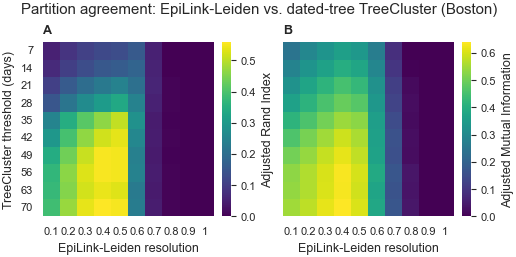

In [ ]:
set_plos_theme()

fig, axes = plt.subplots(
    1, 2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]) * 0.5,
    ),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for ax, matrix, title in (
    (axes[0], ari, "Adjusted Rand Index"),
    (axes[1], ami, "Adjusted Mutual Information"),
):
    sns.heatmap(
        matrix,
        # annot=True,
        # fmt=".2f",
        cmap="viridis",
        vmin=0,
        cbar_kws={"label": title},
        ax=ax,
    )
    ax.set_xlabel("EpiLink-Leiden resolution")

axes[0].set_ylabel("TreeCluster threshold (days)")
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
fig.suptitle("Partition agreement: EpiLink-Leiden vs. dated-tree TreeCluster (Boston)")

add_panel_labels(axes)
_ = save_plos_figure(
    fig, 
    "epilink_vs_treecluster_similarity", 
    out_dir=OUTDIR,
    save_pdf = True,
    save_png = True,
    save_tiff = True,
    save_eps = False,
    )

## Notes

- **Metrics.** Adjusted Rand Index (pair-counting) and BCubed F1 (overlap, the project's
  stability metric) give complementary views; both are chance/structure-aware and handle
  differing cluster counts. Swap `adjusted_rand_score` for `adjusted_mutual_info_score`
  for an information-theoretic alternative.
- **Reading the heatmaps.** High agreement marks (resolution, threshold) pairs where the
  two very different paradigms — pairwise-compatibility graph communities vs. dated
  tree-cut — recover the same grouping. Agreement typically collapses where Leiden
  over-splits (high resolution) relative to TreeCluster's clade count.
- **Shared samples.** Comparison is restricted to samples present in both the EpiLink
  graph and the (possibly clock-filtered) dated tree.
- **EpiLink model.** Uses the matched-baseline stochastic scorer, identical to the
  `boston` pipeline in `src/evaluation/boston.py`.